In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np

from functools import partial 

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

import diffusion_process as dfp

from diffusion_utilities import (
    plot_image_grid,
    plot_image_evolution_rgb,
    animation_images,
)

from score_model import ScoreNet, ConditionalScoreNet
from collections import OrderedDict
from torch.optim import Adam
from tqdm import trange  # progress bars

n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

device ='cpu' 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of threads: 8


In [9]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),  # convert to 28x28 beacuse ScoreNet is designed for 28x28 images
    transforms.ToTensor(),
])

# Train
data_train_full = datasets.CIFAR10(
    root='data',
    train=True,
    download=True,
    transform=transform
)

targets_train = torch.tensor(data_train_full.targets)
cat_indices_train = (targets_train == 3).nonzero(as_tuple=True)[0]   # class 3 = cat
data_train_cats = Subset(data_train_full, cat_indices_train)

# Test
data_test_full = datasets.CIFAR10(
    root='data',
    train=False,
    download=True,
    transform=transform
)

targets_test = torch.tensor(data_test_full.targets)
cat_indices_test = (targets_test == 3).nonzero(as_tuple=True)[0]
data_test_cats = Subset(data_test_full, cat_indices_test)

batch_size = 64

data_loader_cats = DataLoader(
    data_train_cats,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader_cats = DataLoader(
    data_test_cats,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Número de imágenes de entrenamiento (gatos):", len(data_train_cats))
print("Número de imágenes de test (gatos):", len(data_test_cats))

Número de imágenes de entrenamiento (gatos): 5000
Número de imágenes de test (gatos): 1000


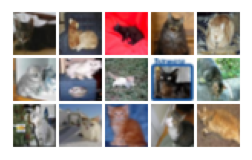

In [10]:
# visualize images
n_rows, n_cols = 3, 5
_ = plot_image_grid(
    images=[data_train_cats[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

# BROWNIAN

In [11]:
# --------------------------------------------------
# Brownian motion (VE)
# dx(t) = sigma^t dW(t)
# --------------------------------------------------
sigma_bm_cats_value = 15.0

def bm_cats_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)

def bm_cats_diffusion_coefficient(t, sigma):
    return sigma ** t

def bm_cats_mu_t(x_0, t):
    return x_0

def bm_cats_sigma_t(t, sigma):
    return torch.sqrt(0.5 * (sigma ** (2 * t) - 1.0) / np.log(sigma))

drift_bm_cats = bm_cats_drift_coefficient
diffusion_bm_cats = partial(bm_cats_diffusion_coefficient, sigma=sigma_bm_cats_value)
mu_bm_cats = bm_cats_mu_t
sigma_bm_cats = partial(bm_cats_sigma_t, sigma=sigma_bm_cats_value)

diffusion_process_bm_cats = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_bm_cats,
    diffusion_coefficient=diffusion_bm_cats,
    mu_t=mu_bm_cats,
    sigma_t=sigma_bm_cats,
)

In [12]:
# --------------------------------------------------
# Score model
# --------------------------------------------------
score_model_bm_cats = ScoreNet(
    marginal_prob_std=partial(bm_cats_sigma_t, sigma=sigma_bm_cats_value), in_channels=3 # NEW: RGB images have 3 channels
).to(device)

In [13]:
# --------------------------------------------------
# Training
# --------------------------------------------------
learning_rate = 1e-4
optimizer_bm_cats = Adam(score_model_bm_cats.parameters(), lr=learning_rate)

# Ajusta esto según tiempo/GPU
n_epochs_cats = 500

tqdm_epoch = trange(n_epochs_cats)

for epoch in tqdm_epoch:
    score_model_bm_cats.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader_cats:
        x = x.to(device)

        loss = diffusion_process_bm_cats.loss_function(score_model_bm_cats, x)

        optimizer_bm_cats.zero_grad()
        loss.backward()
        optimizer_bm_cats.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    mean_loss = avg_loss / num_items
    tqdm_epoch.set_description(f"Average Loss: {mean_loss:.6f}")

    # Guardado robusto
    if isinstance(score_model_bm_cats, torch.nn.DataParallel):
        torch.save(score_model_bm_cats.module.state_dict(), "check_point_bm_cats.pth")
    else:
        torch.save(score_model_bm_cats.state_dict(), "check_point_bm_cats.pth")

Average Loss: 69.015550: 100%|██████████| 500/500 [51:58<00:00,  6.24s/it] 


In [14]:
# ------------------------------------------
# Load checkpoint
# --------------------------------------------------
checkpoint = torch.load("check_point_bm_cats.pth", map_location=device)

new_state_dict = OrderedDict()
for k, v in checkpoint.items():
    new_key = k.replace("module.", "")
    new_state_dict[new_key] = v

score_model_bm_cats.load_state_dict(new_state_dict)
score_model_bm_cats.eval()

ScoreNet(
  (embed): Sequential(
    (0): GaussianRandomFourierFeatures()
    (1): Linear(in_features=256, out_features=256, bias=True)
  )
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (dense1): Dense(
    (dense): Linear(in_features=256, out_features=32, bias=True)
  )
  (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (dense2): Dense(
    (dense): Linear(in_features=256, out_features=64, bias=True)
  )
  (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (dense3): Dense(
    (dense): Linear(in_features=256, out_features=128, bias=True)
  )
  (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (dense4): Dense(
    (dense): Linear(in_features=256, out_features=256, bias=True)
  )
  (gnorm4): GroupNorm(32, 256, eps=1e-05, affine=T

Shape of generated trajectories: torch.Size([9, 3, 28, 28, 501])


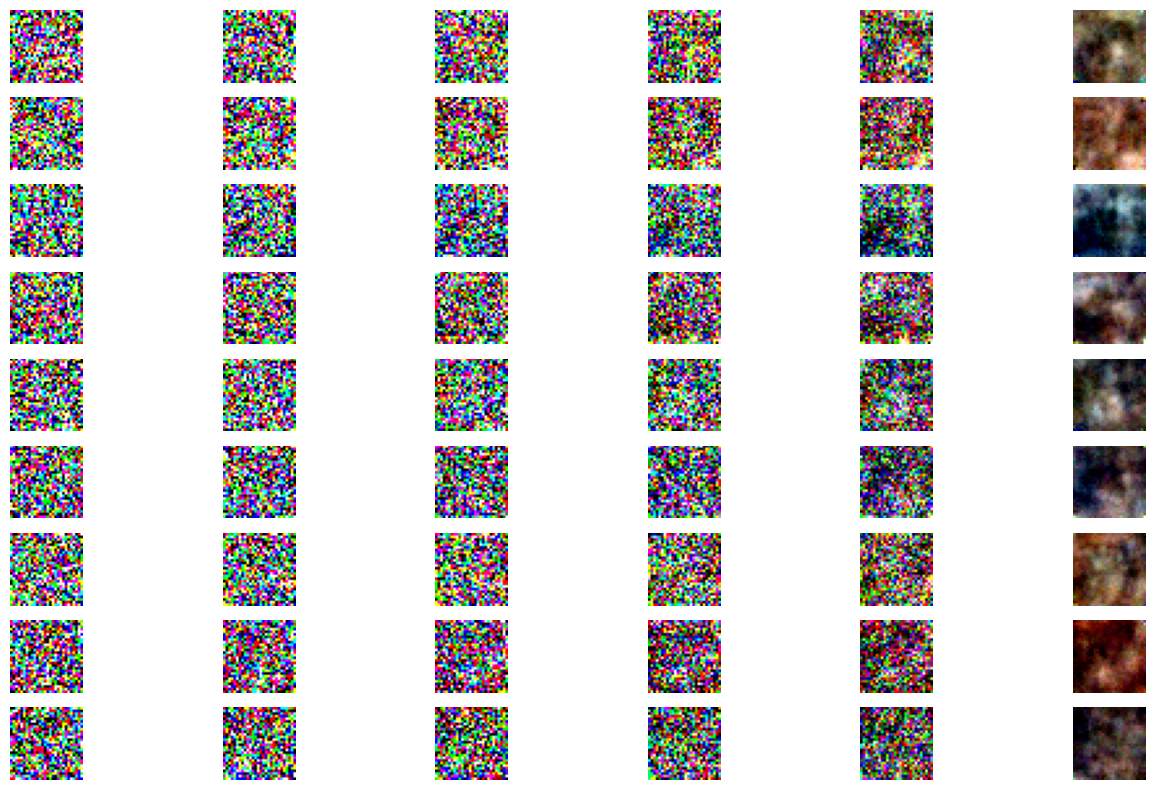

In [15]:
# --------------------------------------------------
# Reverse SDE for Euler-Maruyama
# dx = [f(x,t) - g(t)^2 s_theta(x,t)] dt + g(t) dW
# Here f(x,t)=0 and g(t)=sigma^t
# --------------------------------------------------
def backward_drift_coefficient(x_t, t, diffusion_coefficient, score_model):
    g_t = diffusion_coefficient(t).view(-1, 1, 1, 1)
    return bm_cats_drift_coefficient(x_t, t) - (g_t ** 2) * score_model(x_t, t)

# --------------------------------------------------
# Sampling
# --------------------------------------------------
n_images = 9
T = 1.0
eps = 1.0e-4
n_steps = 500

# Initial condition x(T) ~ N(0, sigma_T^2 I)
sigma_T = bm_cats_sigma_t(
    torch.ones(n_images, device=device) * T,
    sigma_bm_cats_value
).view(-1, 1, 1, 1)

image_T = torch.randn(n_images, 3, 28, 28, device=device) * sigma_T

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        x_0=image_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=diffusion_bm_cats,
            score_model=score_model_bm_cats,
        ),
        diffusion_coefficient=diffusion_bm_cats,
    )

print("Shape of generated trajectories:", synthetic_images_t.shape)

# --------------------------------------------------
# Visualization of the trajectory
# --------------------------------------------------
_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 500],
    figsize=(16, 10),
)

In [16]:
# --------------------------------------------------
# FOR EXERCISE 3: Brownian model objects
# --------------------------------------------------
score_model_brownian = score_model_bm_cats
drift_brownian = bm_cats_drift_coefficient
diffusion_brownian = partial(
    bm_cats_diffusion_coefficient,
    sigma=sigma_bm_cats_value
)

sigma_brownian = partial(
    bm_cats_sigma_t,
    sigma=sigma_bm_cats_value
)

# Ornstein-Uhlenbeck

In [17]:
#1 Using the linear noise schedule.
import torch
import numpy as np
import matplotlib.pyplot as plt

from functools import partial
from collections import OrderedDict

from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.optim import Adam
from tqdm import trange

import diffusion_process as dfp
from score_model import ScoreNet
from diffusion_utilities import plot_image_grid, plot_image_evolution

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [18]:
# These are equal for all the noise schedules, since the forward SDE is the same

# --------------------------------------------------
# Drift and diffusion FORWARD coefficients for the OU process
# --------------------------------------------------
def ou_drift_coefficient(x_t, t, beta_fn):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t

def ou_diffusion_coefficient(t, beta_fn):
    return torch.sqrt(beta_fn(t))

# --------------------------------------------------
# OU marginals
# --------------------------------------------------
def ou_mu_t(x_0, t, alpha_fn):
    alpha_t = alpha_fn(t).view(-1, 1, 1, 1)
    return alpha_t * x_0

def ou_sigma_t(t, alpha_fn):
    alpha_t = alpha_fn(t)
    return torch.sqrt(1.0 - alpha_t**2)

## Linear noise schedule

In [19]:
beta_min = 0.1
beta_max = 20.0

def beta_linear(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t

def A_linear(t, beta_min, beta_max):
    return beta_min * t + 0.5 * (beta_max - beta_min) * t**2

def alpha_linear(t, beta_min, beta_max):
    return torch.exp(-0.5 * A_linear(t, beta_min, beta_max))

In [20]:
beta_fn = partial(beta_linear, beta_min=beta_min, beta_max=beta_max)
alpha_fn = partial(alpha_linear, beta_min=beta_min, beta_max=beta_max)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

In [21]:
# mathematical checks 
t_test = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0])

print("beta(t):", beta_fn(t_test))
print("alpha(t):", alpha_fn(t_test))
print("sigma_t:", sigma_t(t_test))
print("alpha(t)^2 + sigma_t(t)^2:", alpha_fn(t_test)**2 + sigma_t(t_test)**2)

beta(t): tensor([ 0.1000,  5.0750, 10.0500, 15.0250, 20.0000])
alpha(t): tensor([1.0000, 0.7237, 0.2812, 0.0587, 0.0066])
sigma_t: tensor([0.0000, 0.6902, 0.9597, 0.9983, 1.0000])
alpha(t)^2 + sigma_t(t)^2: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [22]:
# gaussian process
diffusion_process = dfp.GaussianDiffussionProcess( 
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [23]:
# score model
score_model = ScoreNet(
    marginal_prob_std=sigma_t, in_channels=3
).to(device)

print(type(score_model))

<class 'score_model.ScoreNet'>


In [24]:
x_batch, y_batch = next(iter(DataLoader(data_train_cats, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)

loss_test = diffusion_process.loss_function(score_model, x_batch)
print(loss_test)

tensor(7046.4927, grad_fn=<MeanBackward0>)


In [26]:
# =========================
# Training
# =========================
batch_size = 64
data_loader_linear = DataLoader(
    data_train_cats,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

learning_rate = 1e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 500
loss_history = []
best_loss = float("inf")

tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader_linear:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(score_model.state_dict(), "best_check_point_ou_linear_CATS.pth")

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:5f}")

  0%|          | 0/500 [00:00<?, ?it/s]

Average Loss: 62.419001: 100%|██████████| 500/500 [52:11<00:00,  6.26s/it]


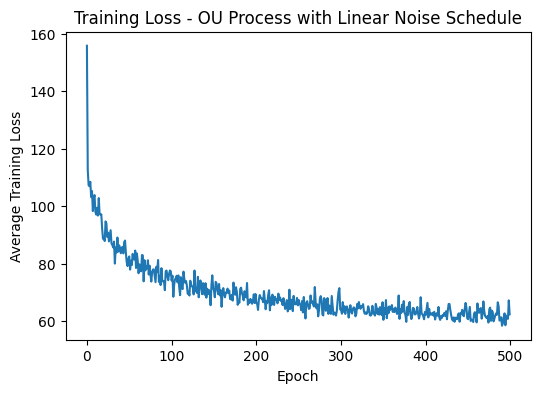

In [27]:
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss - OU Process with Linear Noise Schedule")
plt.show()

In [29]:
# Sampling
score_model.load_state_dict(torch.load("best_check_point_ou_linear_CATS.pth", map_location=device))
score_model.eval()

ScoreNet(
  (embed): Sequential(
    (0): GaussianRandomFourierFeatures()
    (1): Linear(in_features=256, out_features=256, bias=True)
  )
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (dense1): Dense(
    (dense): Linear(in_features=256, out_features=32, bias=True)
  )
  (gnorm1): GroupNorm(4, 32, eps=1e-05, affine=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (dense2): Dense(
    (dense): Linear(in_features=256, out_features=64, bias=True)
  )
  (gnorm2): GroupNorm(32, 64, eps=1e-05, affine=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (dense3): Dense(
    (dense): Linear(in_features=256, out_features=128, bias=True)
  )
  (gnorm3): GroupNorm(32, 128, eps=1e-05, affine=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (dense4): Dense(
    (dense): Linear(in_features=256, out_features=256, bias=True)
  )
  (gnorm4): GroupNorm(32, 256, eps=1e-05, affine=T

In [30]:
# Drift BACKWARD - this is the same for all noise schedules, since the forward SDE is the same
def backward_drift_coefficient(x_t, t, beta_fn, score_model):
    beta_t = beta_fn(t).view(-1, 1, 1, 1)
    return -0.5 * beta_t * x_t - beta_t * score_model(x_t, t)

In [31]:
n_images = 9
T = 1.0
eps = 1.0e-4
n_steps = 500

# Initial condition x(T) ~ N(0, sigma_T^2 I)
# we use seed to compare results with the rest of the types of noise schedules
torch.manual_seed(42)
x_T = torch.randn(n_images, 3, 28, 28, device=device) # change to 3 channels for RGB images

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            beta_fn=beta_fn,
            score_model=score_model,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

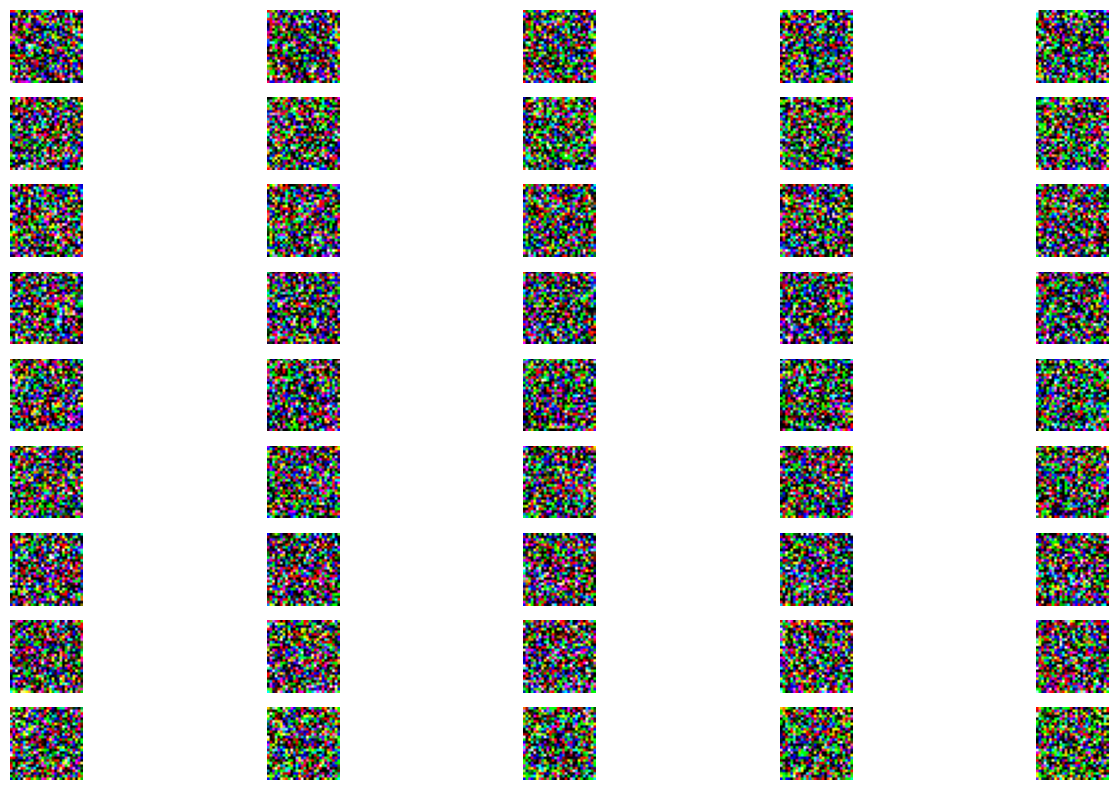

In [ ]:
# visualization
_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=9,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 480, 500],
    figsize=(16, 10),
)

In [33]:
# --------------------------------------------------
# FOR EXERCISE 3: OU linear model objects
# --------------------------------------------------
score_model_ou_linear = score_model
drift_ou_linear = drift_coefficient
diffusion_ou_linear = diffusion_coefficient
sigma_ou_linear = sigma_t

## Cosine noise schedule

In [34]:
# --------------------------------------------------
# Cosine noise schedule for the OU / VP process
# --------------------------------------------------
cosine_s = 0.008
beta_clip_max = 50.0

def alpha_bar_cosine(t, s=0.008):
    """
    Cumulative attenuation factor:
    alpha_bar(t) in [0,1]
    """
    theta_t = (t + s) / (1.0 + s) * (np.pi / 2.0)
    theta_0 = s / (1.0 + s) * (np.pi / 2.0)
    return (torch.cos(theta_t) ** 2) / (np.cos(theta_0) ** 2)

def alpha_cosine(t, s=0.008):
    """
    alpha(t) = sqrt(alpha_bar(t))
    """
    return torch.sqrt(alpha_bar_cosine(t, s=s))

def beta_cosine(t, s=0.008, beta_clip_max=20.0):
    """
    beta(t) = - d/dt log(alpha_bar(t))
            = pi/(1+s) * tan(theta(t))
    """
    theta_t = (t + s) / (1.0 + s) * (np.pi / 2.0)
    beta_t = (np.pi / (1.0 + s)) * torch.tan(theta_t)
    return torch.clamp(beta_t, max=beta_clip_max)

In [35]:
beta_fn = partial(beta_cosine, s=cosine_s, beta_clip_max=beta_clip_max)
alpha_fn = partial(alpha_cosine, s=cosine_s)
alpha_bar_fn = partial(alpha_bar_cosine, s=cosine_s)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

In [36]:
# --------------------------------------------------
# Mathematical checks
# --------------------------------------------------

t_test = torch.tensor([0.0, 0.25, 0.5, 0.75, 0.999])

print("beta(t):", beta_fn(t_test))
print("alpha_bar(t):", alpha_bar_fn(t_test))
print("alpha(t):", alpha_fn(t_test))
print("sigma_t:", sigma_t(t_test))
print("alpha_bar(t) + sigma_t(t)^2:", alpha_bar_fn(t_test) + sigma_t(t_test)**2)

beta(t): tensor([3.8856e-02, 1.3252e+00, 3.1558e+00, 7.5911e+00, 5.0000e+01])
alpha_bar(t): tensor([1.0000e+00, 8.4701e-01, 4.9384e-01, 1.4427e-01, 2.4289e-06])
alpha(t): tensor([1.0000, 0.9203, 0.7027, 0.3798, 0.0016])
sigma_t: tensor([0.0000, 0.3911, 0.7114, 0.9251, 1.0000])
alpha_bar(t) + sigma_t(t)^2: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [37]:
# --------------------------------------------------
# Build diffusion process
# --------------------------------------------------
diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [38]:
# --------------------------------------------------
# Define score model
# --------------------------------------------------
score_model = ScoreNet(
    marginal_prob_std=sigma_t, in_channels=3
).to(device)

print(type(score_model))

# quick loss check
x_batch, y_batch = next(iter(DataLoader(data_train_cats, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)

loss_test = diffusion_process.loss_function(score_model, x_batch)
print("Initial test loss:", loss_test.item())

<class 'score_model.ScoreNet'>
Initial test loss: 8600.9521484375


In [39]:
# --------------------------------------------------
# Training
# --------------------------------------------------

batch_size = 64
data_loader_cosine = DataLoader(
    data_train_cats,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

learning_rate = 1e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 500
tqdm_epoch = trange(n_epochs)

loss_history = []
best_loss = float("inf")

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader_cosine:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(score_model.state_dict(), "best_check_point_ou_cosine_CATS.pth")

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:5f}")

# save final model too
torch.save(score_model.state_dict(), "check_point_ou_cosine_CATS.pth")

Average Loss: 373.579082:   1%|          | 4/500 [00:27<57:17,  6.93s/it] 


KeyboardInterrupt: 

In [ ]:
# --------------------------------------------------
# Loss curve
# --------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss - OU Process with Cosine Noise Schedule")
plt.show()

In [ ]:
# --------------------------------------------------
# Sampling / generation
# --------------------------------------------------

score_model.load_state_dict(torch.load("best_check_point_ou_cosine_CATS.pth", map_location=device))
score_model.eval()

# --------------------------------------------------
# BACKWARD 
# --------------------------------------------------
n_images = 9
T = 0.999
eps = 1.0e-4
n_steps = 500

x_T = torch.randn(n_images, 3, 28, 28, device=device) # change to 3 channels for RGB images

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            beta_fn=beta_fn,
            score_model=score_model,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

print(synthetic_images_t.shape)

In [ ]:
# ------------------------------------------
# visualization of the trajectory
# ------------------------------------------
_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=9,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 480, 500],
    figsize=(16, 10),
)

In [ ]:
# --------------------------------------------------
# FOR EXERCISE 3: OU cosine model objects
# --------------------------------------------------
score_model_ou_cosine = score_model
drift_ou_cosine = drift_coefficient
diffusion_ou_cosine = diffusion_coefficient
sigma_ou_cosine = sigma_t

## Quadratic noise schedule

In [ ]:
# --------------------------------------------------
# Quadratic noise schedule for the OU / VP process
# --------------------------------------------------
beta_min = 0.1
beta_max = 20.0

def beta_quadratic(t, beta_min, beta_max):
    return beta_min + (beta_max - beta_min) * t**2

def A_quadratic(t, beta_min, beta_max):
    return beta_min * t + (beta_max - beta_min) * t**3 / 3.0

def alpha_quadratic(t, beta_min, beta_max):
    return torch.exp(-0.5 * A_quadratic(t, beta_min, beta_max))

In [ ]:
beta_fn = partial(beta_quadratic, beta_min=beta_min, beta_max=beta_max)
alpha_fn = partial(alpha_quadratic, beta_min=beta_min, beta_max=beta_max)

drift_coefficient = partial(ou_drift_coefficient, beta_fn=beta_fn)
diffusion_coefficient = partial(ou_diffusion_coefficient, beta_fn=beta_fn)
mu_t = partial(ou_mu_t, alpha_fn=alpha_fn)
sigma_t = partial(ou_sigma_t, alpha_fn=alpha_fn)

In [ ]:
# --------------------------------------------------
# Mathematical checks
# --------------------------------------------------
t_test = torch.tensor([0.0, 0.25, 0.5, 0.75, 1.0])

print("beta(t):", beta_fn(t_test))
print("A(t):", A_quadratic(t_test, beta_min, beta_max))
print("alpha(t):", alpha_fn(t_test))
print("sigma_t:", sigma_t(t_test))
print("alpha(t)^2 + sigma_t(t)^2:", alpha_fn(t_test)**2 + sigma_t(t_test)**2)

In [ ]:
# --------------------------------------------------
# Build diffusion process
# --------------------------------------------------
diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient=drift_coefficient,
    diffusion_coefficient=diffusion_coefficient,
    mu_t=mu_t,
    sigma_t=sigma_t,
)

In [ ]:
# --------------------------------------------------
# Define score model
# --------------------------------------------------
score_model = ScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=3
).to(device)

print(type(score_model))

# quick loss check
x_batch, y_batch = next(iter(DataLoader(data_train_cats, batch_size=8, shuffle=True)))
x_batch = x_batch.to(device)

loss_test = diffusion_process.loss_function(score_model, x_batch)
print(loss_test)

In [ ]:
# --------------------------------------------------
# Training
# --------------------------------------------------
batch_size = 64
data_loader_quadratic = DataLoader(
    data_train_cats,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

learning_rate = 1e-3
optimizer = Adam(score_model.parameters(), lr=learning_rate)

n_epochs = 500
tqdm_epoch = trange(n_epochs)

loss_history = []
best_loss = float("inf")

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader_quadratic:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    loss_history.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(score_model.state_dict(), "best_check_point_ou_quadratic.pth")

    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:.5f}")

torch.save(score_model.state_dict(), "check_point_ou_quadratic.pth")

In [ ]:
# --------------------------------------------------
# Loss curve
# --------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss - OU Process with Quadratic Noise Schedule")
plt.show()

In [ ]:
# --------------------------------------------------
# Sampling / generation
# --------------------------------------------------
score_model.load_state_dict(torch.load("best_check_point_ou_quadratic.pth", map_location=device))
score_model.eval()

# --------------------------------------------------
# BACKWARD
# --------------------------------------------------
n_images = 9
T = 1.0
eps = 1.0e-4
n_steps = 500

x_T = torch.randn(n_images, 3, 28, 28, device=device) # change to 3 channels for RGB images

with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        x_0=x_T,
        t_0=T,
        t_end=eps,
        n_steps=n_steps,
        drift_coefficient=partial(
            backward_drift_coefficient,
            beta_fn=beta_fn,
            score_model=score_model,
        ),
        diffusion_coefficient=diffusion_coefficient,
    )

print(synthetic_images_t.shape)

In [ ]:
# ------------------------------------------
# visualization of the trajectory
# ------------------------------------------
_ = plot_image_evolution_rgb(
    images=synthetic_images_t,
    n_images=9,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 480, 500],
    figsize=(16, 10),
)

In [ ]:
# --------------------------------------------------
# FOR EXERCISE 3: OU quadratic model objects
# --------------------------------------------------
score_model_ou_quadratic = score_model
drift_ou_quadratic = drift_coefficient
diffusion_ou_quadratic = diffusion_coefficient
sigma_ou_quadratic = sigma_t

# Bits Per Dimension (BPD)

In [ ]:
import torch
import numpy as np
import pandas as pd

def gaussian_logpdf_general(x, std):
    """
    Log-density of a centered isotropic Gaussian N(0, std^2 I).
    x:   (batch, channels, H, W)
    std: (batch, 1, 1, 1)
    """
    dim = x[0].numel()
    x_flat = x.view(x.shape[0], -1)
    var = std.view(-1) ** 2

    return -0.5 * (
        dim * torch.log(torch.tensor(2 * np.pi, device=x.device))
        + dim * torch.log(var)
        + torch.sum(x_flat ** 2, dim=1) / var
    )

def divergence_hutchinson_general(fn, x, t):
    """
    Hutchinson estimator of the divergence.
    """
    eps = torch.randn_like(x)
    x.requires_grad_(True)

    y = fn(x, t)
    inner = torch.sum(y * eps)

    grad = torch.autograd.grad(inner, x, create_graph=False)[0]
    div = torch.sum(grad * eps, dim=(1, 2, 3))
    return div

def make_probability_flow_drift(drift_coefficient, diffusion_coefficient, score_model):
    """
    Returns the drift of the probability flow ODE:
    f_tilde(x,t) = f(x,t) - 0.5 g(t)^2 score(x,t)
    """
    def probability_flow_drift(x_t, t):
        g_t = diffusion_coefficient(t).view(-1, 1, 1, 1)
        return drift_coefficient(x_t, t) - 0.5 * (g_t ** 2) * score_model(x_t, t)
    return probability_flow_drift

def compute_log_likelihood_general(
    x_data,
    score_model,
    drift_coefficient,
    diffusion_coefficient,
    sigma_t,
    T=1.0,
    eps=1e-3,
    n_steps=500
):
    """
    Approximate log p_0(x) using the probability flow ODE.
    """
    score_model.eval()
    device = x_data.device
    batch_size = x_data.shape[0]

    probability_flow_drift = make_probability_flow_drift(
        drift_coefficient=drift_coefficient,
        diffusion_coefficient=diffusion_coefficient,
        score_model=score_model,
    )

    times = torch.linspace(eps, T, n_steps + 1, device=device)
    dt = times[1] - times[0]

    x = x_data.clone()
    delta_logp = torch.zeros(batch_size, device=device)

    for t_scalar in times[:-1]:
        t_batch = torch.ones(batch_size, device=device) * t_scalar

        x = x.detach().requires_grad_(True)
        drift = probability_flow_drift(x, t_batch)

        div = divergence_hutchinson_general(probability_flow_drift, x, t_batch)

        x = (x + drift * dt).detach()
        delta_logp = delta_logp - div.detach() * dt

    sigma_T = sigma_t(torch.ones(batch_size, device=device) * T).view(-1, 1, 1, 1)
    log_pT = gaussian_logpdf_general(x, sigma_T)

    log_p0 = log_pT + delta_logp
    return log_p0

def loglik_to_bpd(log_likelihood, x):
    """
    Convert log-likelihood to bits per dimension.
    """
    num_dims = x[0].numel()
    return -log_likelihood / (num_dims * np.log(2))

def evaluate_bpd_full(
    model_name,
    score_model,
    drift_coefficient,
    diffusion_coefficient,
    sigma_t,
    test_loader,
    T=1.0,
    eps=1e-3,
    n_steps=500,
    max_batches=64
):
    all_loglik = []
    all_bpd = []

    for i, (x_batch, _) in enumerate(test_loader):
        if i >= max_batches:
            break

        x_batch = x_batch.to(device)

        log_likelihoods = compute_log_likelihood_general(
            x_data=x_batch,
            score_model=score_model,
            drift_coefficient=drift_coefficient,
            diffusion_coefficient=diffusion_coefficient,
            sigma_t=sigma_t,
            T=T,
            eps=eps,
            n_steps=n_steps,
        )

        bpd_values = loglik_to_bpd(log_likelihoods, x_batch)

        all_loglik.append(log_likelihoods.detach().cpu())
        all_bpd.append(bpd_values.detach().cpu())

    all_loglik = torch.cat(all_loglik)
    all_bpd = torch.cat(all_bpd)

    return {
        "model": model_name,
        "mean_loglik": all_loglik.mean().item(),
        "mean_bpd": all_bpd.mean().item(),
    }

In [ ]:
results_bpd = []

# Brownian motion
results_bpd.append(
    evaluate_bpd_full(
        "Brownian motion",
        score_model_brownian,
        drift_brownian,
        diffusion_brownian,
        sigma_brownian,
        data_loader_cats,
    )
)

In [ ]:
# OU linear
results_bpd.append(
    evaluate_bpd_full(
        "OU - linear",
        score_model_ou_linear,
        drift_ou_linear,
        diffusion_ou_linear,
        sigma_ou_linear,
        data_loader_linear
    )
)

In [ ]:
# OU cosine
results_bpd.append(
    evaluate_bpd_full(
        "OU - cosine",
        score_model_ou_cosine,
        drift_ou_cosine,
        diffusion_ou_cosine,
        sigma_ou_cosine,
        data_loader_cosine,
        T=0.999,
    )
)

In [ ]:
# OU quadratic
results_bpd.append(
    evaluate_bpd_full(
        "OU - quadratic",
        score_model_ou_quadratic,
        drift_ou_quadratic,
        diffusion_ou_quadratic,
        sigma_ou_quadratic,
        data_loader_quadratic,
    )
)

In [ ]:
df_bpd = pd.DataFrame(results_bpd)
df_bpd = df_bpd.sort_values("mean_bpd", ascending=True).reset_index(drop=True)

display(df_bpd)